# Testing
## Geburten nach Geburtenreihenfolge und Herkunft des Kindes, seit 1998
Datum: 09.08.2023

### Importiere die notwendigen Packages

In [7]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns


Definiere Settings. Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen), 

In [8]:
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

### Zeitvariabeln
Bestimme den aktuellst geladenen Monat. Hier ist es der Stand vor 2 Monaten. 
Bestimme noch weitere evt. sinnvolle Zeitvariabeln.

Zum Unterschied zwischen import datetime und from datedtime import datetime, siehe https://stackoverflow.com/questions/15707532/import-datetime-v-s-from-datetime-import-datetime

#### Zuerst die generellen Zeitvariabeln als Strings

In [9]:
#today_date = datetime.date.today()
#date_time = datetime.datetime.strptime(date_time_string, '%Y-%m-%d %H:%M')
now = datetime.date.today()
date_today = now.strftime("%Y-%m-%d")
year_today = now.strftime("%Y")
year_month_today = now.strftime("%Y-%m")
month_today = now.strftime("%Y")
day_today = now.strftime("%d")
date_day_a_week_ago = (datetime.datetime.now() - datetime.timedelta(days=7)).date()
day_a_week_ago = date_day_a_week_ago.strftime('%Y-%m-%d')

#### Die zu testenden Zeitvariabeln als Strings

Hier mal die folgenden:
- `latest_year_month`: Der aktuellste Datenstand sollte ja immer der heutige Monat minus 2 sein.
- `latest_year`: Der aktuellste Datenstand sollte ja immer der heutige Monat minus 2 sein. Hier wird das damalige Jahr angegeben.
- `five_years_ago`: Und damit nicht immer alle Zeitreihen geprüft werden müssen, kann auch das Jahr vor 5 Jahren definiert werden.

In [10]:
from datetime import datetime, timedelta
from dateutil.relativedelta import *

latest_year_month = now + relativedelta(months=-2)
latest_year_month = latest_year_month.strftime("%Y-%m")
print(latest_year_month)

latest_year = now + relativedelta(months=-2)
latest_year = latest_year.strftime("%Y")
print(latest_year)

five_years_ago  = now + relativedelta(years=-5)
five_years_ago = five_years_ago.strftime("%Y")
print(five_years_ago)

2024-01
2024
2019


#### Und hier noch die Zeitvariabeln als Integers:
- `aktuellesJahr`
- `aktuellerMonat`: Der gerade jetzt aktuelle Monat
- `selectedMonat`: Der aktuellste Monat in den Daten. In der Regel zwei Monate her.

In [11]:
#now = datetime.now() 
int_times = now.timetuple()

aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2

print(aktuellesJahr, 
      aktuellerMonat,
    'datenstand: ', selectedMonat,
     int_times)


2024 3 datenstand:  1 time.struct_time(tm_year=2024, tm_mon=3, tm_mday=13, tm_hour=0, tm_min=0, tm_sec=0, tm_wday=2, tm_yday=73, tm_isdst=-1)


### Importiere einen Datensatz 

- Beachte dabei die Notation des Pfades...
- Definiere mal aktuell noch keine weiteren Parameter beim Import

**Dataset auf INTEG Datenkatalog**:  https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_monat_geburten_quartier_geschl_ag_herkunft_od4030

**Dataset auf PROD Datenkatalog**:  https://data.stadt-zuerich.ch/dataset/bev_monat_geburten_quartier_geschl_ag_herkunft_od4030

In [12]:
#Die Datasets sind nur zum Testen auf INT-DWH-Dropzone. Wenn der Test vorbei ist, sind sie auf PROD. 
# Über den Status kann man einfach switchen

status = "int";
print(status)

int


In [13]:
# Filepath
if status == "prod":
    #fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/DWH/bev_monat_bestand_quartier_geschl_ag_herkunft_od3250/BEV325OD3250.csv"
    fp = r"https://data.stadt-zuerich.ch/dataset/bev_monat_geburten_quartier_geschl_ag_herkunft_od4030/download/BEV403OD4030.csv"
else:  
    fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/INT_DWH/bev_monat_geburten_quartier_geschl_ag_herkunft_od4030/BEV403OD4030.csv"

print(fp)

//szh.loc/ssz/applikationen/OGD_Dropzone/INT_DWH/bev_monat_geburten_quartier_geschl_ag_herkunft_od4030/BEV403OD4030.csv


Beachte, wie das SAS Datum (ohne Format) in ein UNIX Datum umgerechnet und als Datumsformat dargestellt wird! Siehe dazu `https://stackoverflow.com/questions/26923564/convert-sas-numeric-to-python-datetime`

ACHTUNG: ist seit Juni 2023 nicht mehr notwendig, da die Datumsformate nun in ISO-8401 geliefert werden.

In [14]:
# Read the data
data2betested = pd.read_csv(
    fp, 
    sep=',',
    parse_dates=['StichtagDat'],
    # KONVERTIERE DAS SAS DATUM IN EIN UNIXDATUM UND FORMATIERE ES
    #date_parser=lambda s: epoch + datetime.timedelta(days=int(s)),
    low_memory=False    
    )

print('done')


done


In der Folge ein paar erste Tests:

 - 1) Zeige eine kurze Vorschau der importierten Daten
 - 2) Weise die Datentypen aus
 - 3) Zeige die Shape (Umfang) des Datensatzes an

In [15]:
latest_data_month = data2betested.reset_index().StichtagDat.max()
str_latest_data_month= str(latest_data_month)
print("Der aktuellste Monat im Datensatz ist: "+ str_latest_data_month)

Der aktuellste Monat im Datensatz ist: 2024-01-31 00:00:00


In [16]:
#data2betested.sort_values(by=['EreignisDatJahr','EreignisDatMM'], ascending=False).head(3)
data2betested.sort_values('StichtagDat', ascending=False).head(6)

,EreignisDatJahr,EreignisDatMM,EreignisDatMonat,StichtagDat,SexCd,SexLang,HerkunftCd,...,QuarCd,QuarLang,DatenstandCd,DatenstandLang,LebensfaehigkeitCd,LebensfaehigkeitLang,AnzGebuWir
32379,2024,1,Januar,2024-01-31,2,weiblich,2,...,123,Hirzenbach,P,Provisorisch,J,zutreffend,3
32300,2024,1,Januar,2024-01-31,1,männlich,1,...,119,Seebach,P,Provisorisch,J,zutreffend,7
32302,2024,1,Januar,2024-01-31,1,männlich,1,...,122,Schwamendingen-Mitte,P,Provisorisch,J,zutreffend,1
32303,2024,1,Januar,2024-01-31,1,männlich,1,...,123,Hirzenbach,P,Provisorisch,J,zutreffend,1
32305,2024,1,Januar,2024-01-31,1,männlich,2,...,23,Leimbach,P,Provisorisch,J,zutreffend,1
32306,2024,1,Januar,2024-01-31,1,männlich,2,...,24,Enge,P,Provisorisch,J,zutreffend,6


In [17]:
data2betested.dtypes

EreignisDatJahr                  int64
EreignisDatMM                    int64
EreignisDatMonat                object
StichtagDat             datetime64[ns]
SexCd                            int64
SexLang                         object
HerkunftCd                       int64
HerkunftLang                    object
KreisCd                          int64
KreisLang                       object
QuarCd                           int64
QuarLang                        object
DatenstandCd                    object
DatenstandLang                  object
LebensfaehigkeitCd              object
LebensfaehigkeitLang            object
AnzGebuWir                       int64
dtype: object

In [18]:
data2betested.shape

(32380, 17)

Beschreibe einzelne Attribute

In [19]:
data2betested.describe()

,EreignisDatJahr,EreignisDatMM,SexCd,HerkunftCd,KreisCd,QuarCd,AnzGebuWir
count,32380,32380,32380,32380,32380,32380,32380
mean,2011,6,1,1,7,71,4
std,7,3,0,0,3,34,3
min,1998,1,1,1,1,11,1
25%,2004,3,1,1,4,42,2
50%,2011,6,1,1,7,72,3
75%,2017,9,2,2,10,102,5
max,2024,12,2,2,12,123,22


Wie viele Nullwerte gibt es im Datensatz?

In [20]:
data2betested.isnull().sum()

EreignisDatJahr         0
EreignisDatMM           0
EreignisDatMonat        0
StichtagDat             0
SexCd                   0
SexLang                 0
HerkunftCd              0
HerkunftLang            0
KreisCd                 0
KreisLang               0
QuarCd                  0
QuarLang                0
DatenstandCd            0
DatenstandLang          0
LebensfaehigkeitCd      0
LebensfaehigkeitLang    0
AnzGebuWir              0
dtype: int64

### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [21]:
data2betested = data2betested.set_index("StichtagDat")
#data2betested = data2betested.drop(columns=["StichtagDatMM"])


In [22]:
data2betested.info()
data2betested.index.day.unique()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 32380 entries, 1998-01-31 to 2024-01-31
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   EreignisDatJahr       32380 non-null  int64 
 1   EreignisDatMM         32380 non-null  int64 
 2   EreignisDatMonat      32380 non-null  object
 3   SexCd                 32380 non-null  int64 
 4   SexLang               32380 non-null  object
 5   HerkunftCd            32380 non-null  int64 
 6   HerkunftLang          32380 non-null  object
 7   KreisCd               32380 non-null  int64 
 8   KreisLang             32380 non-null  object
 9   QuarCd                32380 non-null  int64 
 10  QuarLang              32380 non-null  object
 11  DatenstandCd          32380 non-null  object
 12  DatenstandLang        32380 non-null  object
 13  LebensfaehigkeitCd    32380 non-null  object
 14  LebensfaehigkeitLang  32380 non-null  object
 15  AnzGebuWir         

Int64Index([31, 28, 30, 29], dtype='int64', name='StichtagDat')

### Einfache Visualisierungen zur Plausi

Exploriere die Daten mit Pivottable.JS

In [23]:
#pivot_ui(data2betested)

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [24]:
data2betested.loc[latest_year_month].head(4)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)


,EreignisDatJahr,EreignisDatMM,EreignisDatMonat,SexCd,SexLang,HerkunftCd,HerkunftLang,...,QuarCd,QuarLang,DatenstandCd,DatenstandLang,LebensfaehigkeitCd,LebensfaehigkeitLang,AnzGebuWir
StichtagDat,,,,,,,,,,,,,,,
2024-01-31,2024,1,Januar,1,männlich,1,Schweizer*in,...,21,Wollishofen,P,Provisorisch,J,zutreffend,7
2024-01-31,2024,1,Januar,1,männlich,1,Schweizer*in,...,23,Leimbach,P,Provisorisch,J,zutreffend,1
2024-01-31,2024,1,Januar,1,männlich,1,Schweizer*in,...,24,Enge,P,Provisorisch,J,zutreffend,5
2024-01-31,2024,1,Januar,1,männlich,1,Schweizer*in,...,31,Alt-Wiedikon,P,Provisorisch,J,zutreffend,2


### Aggregiere Werte nach Zeitausschnitten

Mit den Funktionen zur Zeit kann einfach zwischen Stunden, Tagen, Monaten, etc. gewechselt und aggregiert werden.
Da die Daten bereits aggregiert nach Monaten sind, macht das hier keinen Sinn.
Untenstehendes also nur als BSP


In [25]:
# first we create the sums per week
weekly_sums = data2betested.resample("W").sum()
# then we generate the weekly means for each quarter
data2betested_sel = data2betested[["SexCd","HerkunftCd","AnzGebuWir"]]
quarterly_sums = data2betested_sel.resample("Q").sum()
# for readability we'll revert the values back to integers
quarterly_sums.astype(int).head(3)

,SexCd,HerkunftCd,AnzGebuWir
StichtagDat,,,
1998-03-31,434,415,906
1998-06-30,454,445,880
1998-09-30,427,420,865


### Visualisierungen nach Zeitausschnitten

In [26]:
data2betested.info()
#data2betested

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 32380 entries, 1998-01-31 to 2024-01-31
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   EreignisDatJahr       32380 non-null  int64 
 1   EreignisDatMM         32380 non-null  int64 
 2   EreignisDatMonat      32380 non-null  object
 3   SexCd                 32380 non-null  int64 
 4   SexLang               32380 non-null  object
 5   HerkunftCd            32380 non-null  int64 
 6   HerkunftLang          32380 non-null  object
 7   KreisCd               32380 non-null  int64 
 8   KreisLang             32380 non-null  object
 9   QuarCd                32380 non-null  int64 
 10  QuarLang              32380 non-null  object
 11  DatenstandCd          32380 non-null  object
 12  DatenstandLang        32380 non-null  object
 13  LebensfaehigkeitCd    32380 non-null  object
 14  LebensfaehigkeitLang  32380 non-null  object
 15  AnzGebuWir         

#### Entwicklung Geburten nach Stadtkreis

In [27]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg = data2betested \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM','KreisLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=True) 

myAgg.reset_index().sort_values('EreignisDatJahr', ascending=True).head(3)

,StichtagDat,EreignisDatJahr,EreignisDatMM,KreisLang,sum_WBev
0,1998-01-31,1998,1,Kreis 1,2
92,1998-08-31,1998,8,Kreis 10,28
93,1998-08-31,1998,8,Kreis 1,1


In [28]:
myTitle="Geburten nach Stadtkreis"

highlight = alt.selection(type='single', on='mouseover',
                          fields=['KreisLang'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.loc["2020-11":latest_year_month].reset_index().query('sum_WBev>0'), title=myTitle).encode(
    x=alt.X('StichtagDat', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('KreisLang', legend=alt.Legend(title="Stadtkreise", orient="right"))  
    ,tooltip=['StichtagDat', 'KreisLang', 'sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=900 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(1.5), alt.value(4))
).interactive()

lines + points

alt.LayerChart(...)

#### Entwicklung nach Geschlecht

In [29]:
#myAgg = data2betested.loc["2008-11":"2021-11"] \
myAgg = data2betested \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM', 'SexLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myAgg.reset_index().head(2)

,StichtagDat,EreignisDatJahr,EreignisDatMM,SexLang,sum_WBev
0,2021-01-31,2021,1,weiblich,344
1,2020-01-31,2020,1,männlich,338


In [30]:
myTitle="Geburten nach Geschlecht"
highlight = alt.selection(type='single', on='mouseover',
                          fields=['SexLang'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.reset_index().query('sum_WBev>1'), title=myTitle).encode(
    x=alt.X('StichtagDat', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('SexLang', legend=alt.Legend(title="Geschlecht"))  
    ,tooltip=['StichtagDat', 'SexLang', 'sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=900 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.5), alt.value(4))
).interactive()

lines + points

alt.LayerChart(...)

#### Entwicklung nach Heimat

In [31]:
#myAgg = data2betested.loc["2008-11":"2021-11"] \
myAgg = data2betested \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM', 'HerkunftLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myAgg.reset_index().head(2)

,StichtagDat,EreignisDatJahr,EreignisDatMM,HerkunftLang,sum_WBev
0,2020-01-31,2020,1,Schweizer*in,362
1,2019-01-31,2019,1,Schweizer*in,352


In [32]:
myTitle="Geburten nach Herkunft"

highlight = alt.selection(type='single', on='mouseover',
                          fields=['HerkunftLang'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.reset_index().query('sum_WBev>1'), title=myTitle).encode(
    x=alt.X('StichtagDat', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('HerkunftLang', legend=alt.Legend(title="Herkunft"))  
    ,tooltip=['StichtagDat', 'HerkunftLang', 'sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=900 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.5), alt.value(4))
).interactive()

lines + points    


alt.LayerChart(...)

#### Geburten nach Geburtsmonat seit 2000

In [33]:
myAgg = data2betested.loc["2019-01":latest_year_month]  \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myAgg.reset_index().sort_values('StichtagDat',ascending=False).head(10)

,StichtagDat,EreignisDatJahr,EreignisDatMM,sum_WBev
17,2024-01-31,2024,1,430
60,2023-12-31,2023,12,251
51,2023-11-30,2023,11,353
54,2023-10-31,2023,10,339
45,2023-09-30,2023,9,371
48,2023-08-31,2023,8,359
46,2023-07-31,2023,7,368
20,2023-06-30,2023,6,421
32,2023-05-31,2023,5,392
53,2023-04-30,2023,4,348


In [34]:
myAgg.reset_index().columns

Index(['StichtagDat', 'EreignisDatJahr', 'EreignisDatMM', 'sum_WBev'], dtype='object')

In [35]:
#Achtung, hier läuft etwas falsch. Check it
categories =myAgg.reset_index().EreignisDatMM.apply(str)
categories.sort_values(ascending=True)

0     1
1     1
2     1
3     1
4     1
     ..
28    9
13    9
45    9
29    9
31    9
Name: EreignisDatMM, Length: 61, dtype: object

In [36]:
import plotly.express as px
#https://plotly.com/python/radar-chart/

df=myAgg.reset_index().sort_values("EreignisDatJahr", ascending=True)
fig = px.line_polar(df, r="sum_WBev", theta=categories, color="EreignisDatJahr", 
                    line_close=True,
                    color_discrete_sequence=px.colors.sequential.Plasma_r,
                    template="plotly_dark",)
fig.show()

In [37]:
myTitle="Geburten nach Monat seit 2010"

highlight = alt.selection(type='single', on='mouseover',
                          fields=['EreignisDatJahr'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.reset_index().query('sum_WBev>1'), title=myTitle).encode(
    x=alt.X('EreignisDatMM', axis=alt.Axis(format='.0f', title='Monat'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Geburten'))
    , color=alt.Color('EreignisDatJahr:O', legend=alt.Legend(title="Jahr"), scale=alt.Scale(scheme='goldgreen'))  
    , tooltip=['StichtagDat', 'EreignisDatJahr', 'EreignisDatMM', 'sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.6)
).add_selection(
    highlight
).properties(
    width=900 , height=450
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.9), alt.value(3))
).interactive()

lines + points  

alt.LayerChart(...)

In [38]:
data2betested.dtypes
#data2betested[["EreignisDatMM","EreignisDatMonat"]]

EreignisDatJahr          int64
EreignisDatMM            int64
EreignisDatMonat        object
SexCd                    int64
SexLang                 object
HerkunftCd               int64
HerkunftLang            object
KreisCd                  int64
KreisLang               object
QuarCd                   int64
QuarLang                object
DatenstandCd            object
DatenstandLang          object
LebensfaehigkeitCd      object
LebensfaehigkeitLang    object
AnzGebuWir               int64
dtype: object

### Daten in interaktiver Treemap zeigen
Dazu gibt es eine sehr nützliche Webseite https://plotly.com/python/treemaps/
Zu Farbskalen, siehe: https://plotly.com/python/builtin-colorscales/

#### Aktuelle Geburten nach Stadtkreis, Quartier, Geschlecht und Herkunft

In [39]:
str_latest_data_month
latest_year_month

'2024-01'

In [40]:
myTreemapAgg = data2betested.loc[latest_year_month]  \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM', 'KreisLang','QuarLang','HerkunftLang', 'SexLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myTreemapAgg.reset_index().head(2)

,StichtagDat,EreignisDatJahr,EreignisDatMM,KreisLang,QuarLang,HerkunftLang,SexLang,sum_WBev
0,2024-01-31,2024,1,Kreis 9,Altstetten,Schweizer*in,männlich,19
1,2024-01-31,2024,1,Kreis 3,Sihlfeld,Schweizer*in,männlich,17


In [41]:
fig = px.treemap(myTreemapAgg.reset_index(), path=[px.Constant("Geburten nach Stadtkreis, Quartier und Alter"), 'KreisLang','QuarLang','SexLang', 'HerkunftLang']
                 , values='sum_WBev'
                 , color='sum_WBev'
                 ## bei discrete scales (bei Klassen und Strings):                 
                 #, color_discrete_map={'(?)':'lightgrey','EVP':'gold', 'SP':'#FF3030', 'PdA':'#EE3B3B', 'Grüne':'#A2CD5A','GLP':'#CAFF70','Die Mitte':'orange','FDP':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }                
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='Blues'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir'])  
                 #,height=400
                 #,width=1500                 
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))
fig.show()

#### Aktueller Geburten nach Stadtkreis und Geschlecht

In [42]:
myTreemapAgg = data2betested.loc[latest_year_month]  \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM', 'KreisLang','SexLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myTreemapAgg.reset_index().head(2)

,StichtagDat,EreignisDatJahr,EreignisDatMM,KreisLang,SexLang,sum_WBev
0,2024-01-31,2024,1,Kreis 11,männlich,45
1,2024-01-31,2024,1,Kreis 9,männlich,37


In [43]:
fig = px.treemap(myTreemapAgg.reset_index()
                 , path=[px.Constant("Geburten nach Alter, Stadtkreis und Herkunft"), 'KreisLang', 'SexLang']
                 , values='sum_WBev'
                 , color='sum_WBev'
                 ## bei discrete scales (bei Klassen und Strings):                 
                 #, color_discrete_map={'(?)':'lightgrey','EVP':'gold', 'SP':'#FF3030', 'PdA':'#EE3B3B', 'Grüne':'#A2CD5A','GLP':'#CAFF70','Die Mitte':'orange','FDP':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }                
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='PuBuGn'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir']) 
                 #,height=400
                 #,width=1500
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))#, title="WBev nach Alter, Stadtkreis und Herkunft")
fig.show()

-------------------------- hier gestoppt

Liniendiagramm 
[Link zur Doku](https://altair-viz.github.io/gallery/multiline_highlight.html)

#### Aktueller Geburten nach Stadtkreis und Geschlecht

In [44]:
myTreemapAgg = data2betested.loc["2020-01":"2022-07"]  \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM', 'KreisLang','SexLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myTreemapAgg.reset_index().sort_values('StichtagDat',ascending=False)

,StichtagDat,EreignisDatJahr,EreignisDatMM,KreisLang,SexLang,sum_WBev
710,2022-07-31,2022,7,Kreis 1,weiblich,1
584,2022-07-31,2022,7,Kreis 8,weiblich,9
553,2022-07-31,2022,7,Kreis 12,weiblich,11
719,2022-07-31,2022,7,Kreis 1,männlich,1
394,2022-07-31,2022,7,Kreis 7,weiblich,16
...,...,...,...,...,...,...
334,2020-01-31,2020,1,Kreis 8,männlich,18
435,2020-01-31,2020,1,Kreis 4,weiblich,15
450,2020-01-31,2020,1,Kreis 4,männlich,15
470,2020-01-31,2020,1,Kreis 5,männlich,14


In [45]:
fig = px.treemap(myTreemapAgg.reset_index()
                 , path=[px.Constant("Geburten nach Alter, Stadtkreis und Herkunft"),'EreignisDatMM', 'EreignisDatJahr']
                 , values='sum_WBev'
                 , color='sum_WBev'
                 ## bei discrete scales (bei Klassen und Strings):                 
                 #, color_discrete_map={'(?)':'lightgrey','EVP':'gold', 'SP':'#FF3030', 'PdA':'#EE3B3B', 'Grüne':'#A2CD5A','GLP':'#CAFF70','Die Mitte':'orange','FDP':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }                
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='PuBuGn'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir']) 
                 ,height=500
                 #,width=1500
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))#, title="WBev nach Alter, Stadtkreis und Herkunft")
fig.show()

### Test: Choroplethenkarte
Importiere die Geodaten als GeoJSON

In [46]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
# Wenn die Daten lokal agelegt sind, dann kannst Du folgendes machen:
##input_stadtquartiere = r"//szh.loc/ssz/data/GIS/Daten/Vektor/_aktuell/stzh.adm_statistische_quartiere_map.json"
##df_stadtquartiere = gpd.read_file(input_stadtquartiere)
##df_stadtquartiere.head(2)
#df_stadtkreise.dtypes

geojson_url = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_map"
df_adm_statistische_quartiere_map = gpd.read_file(geojson_url)

df_adm_statistische_quartiere_map.head(5)


,id,kname,knr,objectid,objid,qname,qnr,geometry
0,adm_statistische_quartiere_map.1,Kreis 7,7,1,34,Hirslanden,73,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ..."
1,adm_statistische_quartiere_map.2,Kreis 8,8,2,33,Weinegg,83,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ..."
2,adm_statistische_quartiere_map.3,Kreis 8,8,3,32,Mühlebach,82,"POLYGON ((8.55423 47.36456, 8.55426 47.36452, ..."
3,adm_statistische_quartiere_map.4,Kreis 8,8,4,31,Seefeld,81,"POLYGON ((8.54795 47.36500, 8.54805 47.36489, ..."
4,adm_statistische_quartiere_map.7,Kreis 4,4,7,16,Werd,41,"POLYGON ((8.53300 47.37394, 8.53299 47.37392, ..."


Joine die importierten statistischen Daten des aktuellen Jahres zum Geodatensatz:

*Siehe dazu Doku zu [Geopandas](https://geopandas.org/docs/user_guide/mergingdata.html)*

In [47]:
data2betested.loc[latest_year_month].reset_index().head(2)

,StichtagDat,EreignisDatJahr,EreignisDatMM,EreignisDatMonat,SexCd,SexLang,HerkunftCd,...,QuarCd,QuarLang,DatenstandCd,DatenstandLang,LebensfaehigkeitCd,LebensfaehigkeitLang,AnzGebuWir
0,2024-01-31,2024,1,Januar,1,männlich,1,...,21,Wollishofen,P,Provisorisch,J,zutreffend,7
1,2024-01-31,2024,1,Januar,1,männlich,1,...,23,Leimbach,P,Provisorisch,J,zutreffend,1


In [48]:
akt_wbev_quart = data2betested.loc[latest_year].groupby(
    ['EreignisDatJahr','QuarCd','QuarLang']
).agg(
    {'AnzGebuWir':'sum'}
)
akt_wbev_quart.reset_index().sort_values('AnzGebuWir', ascending=False).head()


,EreignisDatJahr,QuarCd,QuarLang,AnzGebuWir
22,2024,92,Altstetten,47
25,2024,111,Affoltern,32
6,2024,34,Sihlfeld,27
24,2024,102,Wipkingen,25
27,2024,119,Seebach,25


In [49]:
# Rename attribute stznr to StatZoneSort, so the IDs have the same name
stadtquartiere_shapes = df_adm_statistische_quartiere_map[['geometry', 'qnr', 'qname', 'knr']].rename(columns={'qnr': 'QuarCd'})

# Merge with `merge` method on shared variable (stznr und StatZoneSort):
stadtquartiere_shapes_joined = stadtquartiere_shapes.merge(akt_wbev_quart.reset_index(), on='QuarCd')

stadtquartiere_shapes_joined.head(2)


,geometry,QuarCd,qname,knr,EreignisDatJahr,QuarLang,AnzGebuWir
0,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ...",73,Hirslanden,7,2024,Hirslanden,11
1,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ...",83,Weinegg,8,2024,Weinegg,2


<AxesSubplot:>

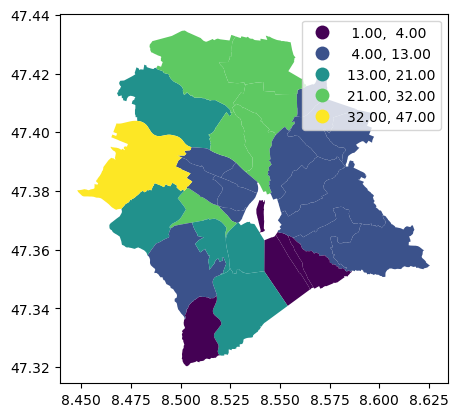

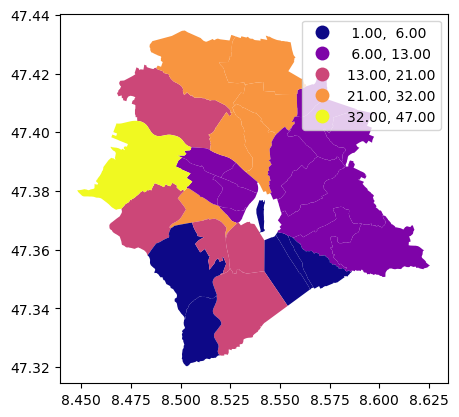

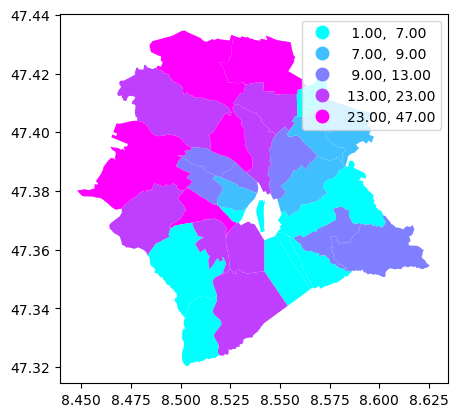

In [50]:
# Plot by StatQuartiere
# Weitere Schemes: scheme='quantiles', scheme='fisherjenks', scheme='natural_breaks',

stadtquartiere_shapes_joined.plot(column='AnzGebuWir', cmap='viridis', scheme='natural_breaks', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html

stadtquartiere_shapes_joined.plot(column='AnzGebuWir', cmap='plasma', scheme='fisherjenks', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html
stadtquartiere_shapes_joined.plot(column='AnzGebuWir', cmap='cool', scheme='quantiles', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html

#
#Neuere Gallerie: https://matplotlib.org/stable/gallery/index.html

Noch zu prüfen, folgendes schöne Beispiel: https://docs.bokeh.org/en/latest/docs/user_guide/interaction/legends.html

Konkrete Beispiele von Bookeh in Jupyter NB: https://docs.bokeh.org/en/latest/docs/user_guide/jupyter.html

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](http://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/EditForm.aspx?ID=157&Source=%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs)**